<a href="https://colab.research.google.com/github/Anatole04/smart-cities-thermique/blob/main/SmartCities_Thermique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
# Téléchargement automatique depuis GitHub
import urllib.request
import os

repo = "https://raw.githubusercontent.com/Anatole04/smart-cities-thermique/main"

# Télécharger dm4bem.py
if not os.path.exists('dm4bem.py'):
    urllib.request.urlretrieve(f"{repo}/dm4bem.py", "dm4bem.py")
    print("✅ dm4bem.py téléchargé")

# Télécharger le fichier EPW
if not os.path.exists('FRA_Lyon.074810_IWEC.epw'):
    urllib.request.urlretrieve(f"{repo}/FRA_Lyon.074810_IWEC.epw",
                               "FRA_Lyon.074810_IWEC.epw")
    print("✅ EPW téléchargé")

import sys
sys.path.insert(0, '.')
import dm4bem

EPW_FILE = 'FRA_Lyon.074810_IWEC.epw'
print("✅ Prêt !")

✅ dm4bem.py téléchargé
✅ EPW téléchargé
✅ Prêt !


In [28]:
## ============================================================
## SECTION 6 — Valeurs des Conductances Thermiques
## Smart Cities — Modélisation Thermique
## ============================================================

import numpy as np
import pandas as pd

print("=" * 55)
print("SECTION 6 — Conductances thermiques")
print("=" * 55)

# ── Propriétés des matériaux (Table 1 du rapport) ────────────────
lambda_b   = 1.70   # W/(m·K)  béton plein
lambda_ldv = 0.04   # W/(m·K)  laine de verre
hi = 8.0            # W/(m²·K) convection intérieure
he = 25.0           # W/(m²·K) convection extérieure
U_vitrage   = 1.5   # W/(m²·K) double vitrage
U_porte_ext = 1.5   # W/(m²·K) porte extérieure aluminium
U_porte_int = 2.5   # W/(m²·K) porte intérieure

# ── Épaisseurs ───────────────────────────────────────────────────
e_mur_ext = 0.40    # m  mur extérieur total
e_beton   = 0.60 * e_mur_ext   # 0.24 m  (60% béton)
e_ldv     = 0.40 * e_mur_ext   # 0.16 m  (40% laine de verre)
e_refend  = 0.20    # m  mur de refend béton pur

# ── Surfaces ─────────────────────────────────────────────────────
A_sud      = 13.0*3.0 - 2*(1.5*1.0)   # 36.0 m²  mur Sud opaque
A_fen      = 2*(1.5*1.0)               #  3.0 m²  fenêtres Sud
A_est      = 5.8*3.0  - 1.0*2.0       # 15.4 m²  mur Est opaque
A_porte_ext = 1.0*2.0                  #  2.0 m²  porte ext aluminium
A_refend   = 5.0*3.0  - 1.0*2.0       # 13.0 m²  mur de refend
A_porte_int = 1.0*2.0                  #  2.0 m²  porte intérieure

print("\n── Surfaces de l'enveloppe ──")
surfaces = {
    'Mur Sud opaque'   : A_sud,
    'Fenêtres Sud (×2)': A_fen,
    'Mur Est opaque'   : A_est,
    'Porte ext. Est'   : A_porte_ext,
    'Mur de refend'    : A_refend,
    'Porte intérieure' : A_porte_int,
}
for nom, aire in surfaces.items():
    print(f"  {nom:22s} = {aire:.1f} m²")

# ── Résistances thermiques ────────────────────────────────────────
R_cond_ext = e_beton/lambda_b + e_ldv/lambda_ldv   # conduction mur ext
R_refend   = 1/hi + e_refend/lambda_b + 1/hi        # mur de refend total
U_mur_ext  = 1 / (1/he + R_cond_ext + 1/hi)        # U global mur ext
U_refend   = 1 / R_refend                           # U global refend

print("\n── Transmittances globales (vérification) ──")
print(f"  R_cond_ext (sans convection) = {R_cond_ext:.3f} m²K/W")
print(f"  U_mur_ext  (avec convection) = {U_mur_ext:.4f} W/(m²K)")
print(f"  U_refend                     = {U_refend:.4f} W/(m²K)")

# ── Conductances G [W/K] ─────────────────────────────────────────
# Approche B — nœuds de surface séparés (fidèle au circuit Fig.3)
# Murs opaques : 3 branches (conv ext / conduction / conv int)
# Fenêtres + portes + infiltrations : advection globale G_flow
# Wall (refend) : conductance U×A globale (bloc jaune Fig.3)
# Porte ext : conductance U×A (blocs cyan+bleu entre θ5, θ6, θ7)

G_flow_hiver = 18.0    # W/K  (0.5 vol/h, section 4.3)
G_flow_ete   = 195.0   # W/K  (6.5 vol/h, section 4.3)

conductances = {
    'q0  conv ext Sud'        : he * A_sud,
    'q1  cond composite Sud'  : A_sud / R_cond_ext,
    'q2  conv int Sud'        : hi * A_sud,
    'q3  Window advection P1' : G_flow_hiver,
    'q4  Contrôleur P1'       : float('inf'),
    'q5  Wall (refend U×A)'   : U_refend * A_refend,
    'q6  Door int advection'  : G_flow_hiver,
    'q7  conv ext Est'        : he * A_sud,
    'q8  cond composite Est'  : A_sud / R_cond_ext,
    'q9  conv int Est'        : hi * A_sud,
    'q10 Window advection P2' : G_flow_hiver,
    'q11 Contrôleur P2'       : float('inf'),
    'q12 conv int mur hall'   : hi * A_est,
    'q13 cond mur hall'       : A_est / R_cond_ext,
    'q14 conv ext mur hall'   : he * A_est,
    'q15 Door ext advection'  : G_flow_hiver,
}

print("\n── Conductances hiver [W/K] ──")
print(f"  {'Branche':<30s}  {'G [W/K]':>10}")
print("  " + "-"*42)
for nom, g in conductances.items():
    val = f"{g:.2f}" if g != float('inf') else "Kp → ∞"
    print(f"  {nom:<30s}  {val:>10}")

# Tableau récap pandas
df_G = pd.DataFrame([
    {'Branche': k, 'G_hiver [W/K]': v if v != float('inf') else 'Kp',
     'G_été [W/K]': (G_flow_ete if 'advection' in k else
                     (v if v != float('inf') else 'Kp'))}
    for k, v in conductances.items()
])
print("\n── Tableau récapitulatif ──")
print(df_G.to_string(index=False))

# ── Conductance globale bâtiment (pour DJU section 9) ───────────
G_bat_hiver = (U_mur_ext*2*A_sud + U_mur_ext*A_est +
               U_refend*A_refend + G_flow_hiver)
G_bat_ete   = (U_mur_ext*2*A_sud + U_mur_ext*A_est +
               U_refend*A_refend + G_flow_ete)

print(f"\n── Conductance globale bâtiment ──")
print(f"  G_bât hiver = {G_bat_hiver:.2f} W/K")
print(f"  G_bât été   = {G_bat_ete:.2f} W/K")

SECTION 6 — Conductances thermiques

── Surfaces de l'enveloppe ──
  Mur Sud opaque         = 36.0 m²
  Fenêtres Sud (×2)      = 3.0 m²
  Mur Est opaque         = 15.4 m²
  Porte ext. Est         = 2.0 m²
  Mur de refend          = 13.0 m²
  Porte intérieure       = 2.0 m²

── Transmittances globales (vérification) ──
  R_cond_ext (sans convection) = 4.141 m²K/W
  U_mur_ext  (avec convection) = 0.2322 W/(m²K)
  U_refend                     = 2.7200 W/(m²K)

── Conductances hiver [W/K] ──
  Branche                            G [W/K]
  ------------------------------------------
  q0  conv ext Sud                    900.00
  q1  cond composite Sud                8.69
  q2  conv int Sud                    288.00
  q3  Window advection P1              18.00
  q4  Contrôleur P1                   Kp → ∞
  q5  Wall (refend U×A)                35.36
  q6  Door int advection               18.00
  q7  conv ext Est                    900.00
  q8  cond composite Est                8.69
  q9  conv i

Conductances hiver [W/K] :
  q 0 : 900.00
  q 1 : 8.69
  q 2 : 288.00
  q 3 : 18.00
  q 4 : 1000000.00
  q 5 : 35.36
  q 6 : 18.00
  q 7 : 385.00
  q 8 : 3.72
  q 9 : 123.20
  q10 : 18.00
  q11 : 1000000.00
  q12 : 16.00
  q13 : 3.00
  q14 : 50.00
  q15 : 18.00

── Scénario HIVER ──
  T_ext=3.0°C | T_sp=19.0°C | T_hall=13.0°C | E=12.0 W/m²
  phi_Sud=10.06 W | phi_Est=4.30 W | Q=80.0 W → θ5

── Scénario ETE ──
  T_ext=25.0°C | T_sp=23.0°C | T_hall=22.0°C | E=100.0 W/m²
  phi_Sud=83.85 W | phi_Est=35.87 W | Q=80.0 W → θ5

── Températures nodales — HIVER ──
  surf ext Sud (θ0)          = 3.16 °C
  surf int Sud (θ1)          = 18.57 °C
  air P1     (θ2)            = 19.00 °C
  surf ext Est (θ3)          = 3.16 °C
  surf int Est (θ4)          = 18.57 °C
  air P2     (θ5)            = 19.00 °C
  surf porte P2 (θ6)         = 18.10 °C
  surf porte hall(θ7)        = 13.29 °C

── Températures nodales — ÉTÉ ──
  surf ext Sud (θ0)          = 25.08 °C
  surf int Sud (θ1)          = 23.34 °C
  air P

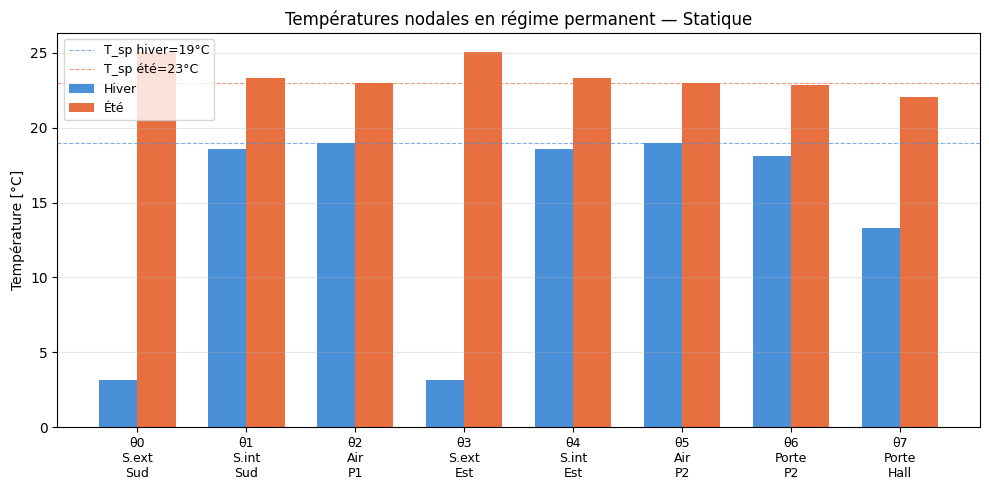

Figure sauvegardée : temperatures_statique.png


In [29]:
## ============================================================
## SECTION 7 — Modèle Mathématique Statique
## Smart Cities — Modélisation Thermique
## ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. CONDUCTANCES ──────────────────────────────────────────────
hi, he = 8.0, 25.0
lambda_b   = 1.70
lambda_ldv = 0.04
e_beton = 0.24
e_ldv   = 0.16
e_ref   = 0.20

A_sud   = 13.0*3.0 - 2*1.5*1.0   # 36.0 m²
A_est   = 5.8*3.0  - 1.0*2.0     # 15.4 m²
A_ref   = 5.0*3.0  - 1.0*2.0     # 13.0 m²
A_porte = 1.0*2.0                 #  2.0 m²

R_cond_ext  = e_beton/lambda_b + e_ldv/lambda_ldv  # 4.141 m²K/W
U_porte_ext = 1.5   # W/m²K

Kp = 1e6

def make_G(season='hiver'):
    """
    Construit la matrice diagonale des conductances G.

    Parameters
    ----------
    season : str
        'hiver' ou 'ete'

    Returns
    -------
    G : np.ndarray (16x16)
        Matrice diagonale des conductances [W/K]
    """
    G_flow = 18.0 if season == 'hiver' else 195.0
    # q5 (Wall) : modélisé comme U_refend × A_ref (convection+conduction+convection)
    R_refend = 1/hi + e_ref/lambda_b + 1/hi   # 0.368 m²K/W
    U_refend = 1 / R_refend                    # 2.72 W/m²K
    g = np.array([
        he * A_sud,              # q0  conv ext Sud
        A_sud / R_cond_ext,      # q1  cond composite Sud
        hi * A_sud,              # q2  conv int Sud
        G_flow,                  # q3  Window advection P1
        Kp,                      # q4  contrôleur P1
        U_refend * A_ref,        # q5  Wall (U×A refend global)
        G_flow,                  # q6  Door int advection
        he * A_est,              # q7  conv ext Est
        A_est / R_cond_ext,      # q8  cond composite Est
        hi * A_est,              # q9  conv int Est
        G_flow,                  # q10 Window advection P2
        Kp,                      # q11 contrôleur P2
        hi * A_porte,            # q12 conv int porte ext
        U_porte_ext * A_porte,   # q13 cond porte ext
        he * A_porte,            # q14 conv ext porte hall
        G_flow,                  # q15 Door ext advection hall
    ])
    return np.diag(g)

G_hiver = make_G('hiver')
G_ete   = make_G('ete')

print("Conductances hiver [W/K] :")
for i, g in enumerate(np.diag(G_hiver)):
    print(f"  q{i:2d} : {g:.2f}")

# ── 2. MATRICE D'INCIDENCE A ─────────────────────────────────────
A = np.array([
    [ 1,  0,  0,  0,  0,  0,  0,  0],  # q0  T_ext → θ0
    [-1,  1,  0,  0,  0,  0,  0,  0],  # q1  θ0 → θ1
    [ 0, -1,  1,  0,  0,  0,  0,  0],  # q2  θ1 → θ2
    [ 0,  0,  1,  0,  0,  0,  0,  0],  # q3  T_ext → θ2
    [ 0,  0,  1,  0,  0,  0,  0,  0],  # q4  T_sp → θ2
    [ 0,  0, -1,  0,  0,  1,  0,  0],  # q5  θ2 ↔ θ5 (Wall)
    [ 0,  0, -1,  0,  0,  1,  0,  0],  # q6  θ2 ↔ θ5 (Door int)
    [ 0,  0,  0,  1,  0,  0,  0,  0],  # q7  T_ext → θ3
    [ 0,  0,  0, -1,  1,  0,  0,  0],  # q8  θ3 → θ4
    [ 0,  0,  0,  0, -1,  1,  0,  0],  # q9  θ4 → θ5
    [ 0,  0,  0,  0,  0,  1,  0,  0],  # q10 T_ext → θ5
    [ 0,  0,  0,  0,  0,  1,  0,  0],  # q11 T_sp → θ5
    [ 0,  0,  0,  0,  0,  1, -1,  0],  # q12 θ5 → θ6
    [ 0,  0,  0,  0,  0,  0,  1, -1],  # q13 θ6 → θ7
    [ 0,  0,  0,  0,  0,  0,  0,  1],  # q14 T_hall → θ7
    [ 0,  0,  0,  0,  0,  1,  0,  0],  # q15 T_hall → θ5
], dtype=float)

# ── 3. VECTEURS b ET f ───────────────────────────────────────────
def build_b_f(season='hiver'):
    """
    Construit les vecteurs des sources de température b et de flux f.

    Parameters
    ----------
    season : str
        'hiver' ou 'ete'. Détermine T_ext, T_sp, T_hall et E.

    Returns
    -------
    b : np.ndarray (16,)
        Vecteur des sources de température sur chaque branche [°C].
        Vaut 0 pour les branches internes (sans source extérieure).
    f : np.ndarray (8,)
        Vecteur des sources de flux sur chaque nœud [W].
        Contient les apports solaires phi0, phi1 et la chaleur
        métabolique Q = 80 W injectée sur le nœud θ5 (air P2).
    """
    if season == 'hiver':
        T_ext, T_sp, T_hall, E = 3.0, 19.0, 13.0, 12.0
    else:
        T_ext, T_sp, T_hall, E = 25.0, 23.0, 22.0, 100.0

    Q, S_fen = 80.0, 3.0
    S_total  = A_sud + A_est + A_ref
    phi0_sud = (A_sud / S_total) * 0.5 * E * S_fen
    phi1_sud = phi0_sud
    phi0_est = (A_est / S_total) * 0.5 * E * S_fen
    phi1_est = phi0_est

    b = np.array([
        T_ext,   # q0
        0,       # q1
        0,       # q2
        T_ext,   # q3  Window
        T_sp,    # q4  contrôleur P1
        0,       # q5  Wall interne
        0,       # q6  Door int interne
        T_ext,   # q7
        0,       # q8
        0,       # q9
        T_ext,   # q10 Window
        T_sp,    # q11 contrôleur P2
        0,       # q12
        0,       # q13
        T_hall,  # q14 ✅ couloir
        T_hall,  # q15 ✅ Door ext vers couloir
    ])

    f = np.array([
        phi0_sud,  # θ0
        phi1_sud,  # θ1
        0,         # θ2 air P1
        phi0_est,  # θ3
        phi1_est,  # θ4
        Q,         # θ5 air P2
        0,         # θ6
        0,         # θ7
    ])

    print(f"\n── Scénario {season.upper()} ──")
    print(f"  T_ext={T_ext}°C | T_sp={T_sp}°C | T_hall={T_hall}°C | E={E} W/m²")
    print(f"  phi_Sud={phi0_sud:.2f} W | phi_Est={phi0_est:.2f} W | Q={Q} W → θ5")
    return b, f

b_hiver, f_hiver = build_b_f('hiver')
b_ete,   f_ete   = build_b_f('ete')

# ── 4. RÉSOLUTION ────────────────────────────────────────────────
def solve_static(A, G, b, f, season=''):
    """
    Résout le système statique nodal : θ = (A^T G A)^{-1} (A^T G b + f).

    Parameters
    ----------
    A : np.ndarray (16, 8)
        Matrice d'incidence du circuit thermique.
    G : np.ndarray (16, 16)
        Matrice diagonale des conductances [W/K].
    b : np.ndarray (16,)
        Vecteur des sources de température [°C].
    f : np.ndarray (8,)
        Vecteur des sources de flux [W].
    season : str
        Label affiché dans les résultats ('HIVER' ou 'ÉTÉ').

    Returns
    -------
    theta : np.ndarray (8,)
        Températures nodales en régime permanent [°C].
    """
    AtGA = A.T @ G @ A
    rhs  = A.T @ G @ b + f
    theta = np.linalg.solve(AtGA, rhs)
    labels = ['surf ext Sud (θ0)', 'surf int Sud (θ1)', 'air P1     (θ2)',
              'surf ext Est (θ3)', 'surf int Est (θ4)', 'air P2     (θ5)',
              'surf porte P2 (θ6)', 'surf porte hall(θ7)']
    print(f"\n── Températures nodales — {season} ──")
    for lab, T in zip(labels, theta):
        print(f"  {lab:26s} = {T:.2f} °C")
    return theta

theta_hiver = solve_static(A, G_hiver, b_hiver, f_hiver, 'HIVER')
theta_ete   = solve_static(A, G_ete,   b_ete,   f_ete,   'ÉTÉ')

# ── 5. TEST DE COHÉRENCE CORRECT ─────────────────────────────────
# Quand T_ext = T_sp = T_hall = 10°C et flux = 0,
# tous les nœuds doivent valoir 10°C.
# IMPORTANT : seules les branches avec source extérieure ont b != 0
print("\n── Test de cohérence (T_ext=T_sp=T_hall=10°C, flux=0) ──")
T_test = 10.0
b_test = np.array([
    T_test,  # q0  T_ext
    0,       # q1  interne
    0,       # q2  interne
    T_test,  # q3  T_ext (Window)
    T_test,  # q4  T_sp = 10
    0,       # q5  interne (Wall)
    0,       # q6  interne (Door int)
    T_test,  # q7  T_ext
    0,       # q8  interne
    0,       # q9  interne
    T_test,  # q10 T_ext (Window)
    T_test,  # q11 T_sp = 10
    0,       # q12 interne
    0,       # q13 interne
    T_test,  # q14 T_hall = 10
    T_test,  # q15 T_hall = 10
])
f_test = np.zeros(8)
theta_test = np.linalg.solve(A.T @ G_hiver @ A,
                              A.T @ G_hiver @ b_test + f_test)
err = np.max(np.abs(theta_test - T_test))
print(f"  Températures : {np.round(theta_test, 4)}")
print(f"  Max écart à {T_test}°C : {err:.2e} °C  {'✅ OK' if err < 1e-6 else '❌ ERREUR'}")

# ── 6. VISUALISATION ─────────────────────────────────────────────
labels_short = ['θ0\nS.ext\nSud', 'θ1\nS.int\nSud', 'θ2\nAir\nP1',
                'θ3\nS.ext\nEst', 'θ4\nS.int\nEst', 'θ5\nAir\nP2',
                'θ6\nPorte\nP2', 'θ7\nPorte\nHall']
x = np.arange(8)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, theta_hiver, width, label='Hiver', color='#4A90D9')
ax.bar(x + width/2, theta_ete,   width, label='Été',   color='#E87040')
ax.axhline(19, color='#4A90D9', linestyle='--', lw=0.8, alpha=0.7, label='T_sp hiver=19°C')
ax.axhline(23, color='#E87040', linestyle='--', lw=0.8, alpha=0.7, label='T_sp été=23°C')
ax.set_xticks(x)
ax.set_xticklabels(labels_short, fontsize=9)
ax.set_ylabel('Température [°C]')
ax.set_title('Températures nodales en régime permanent — Statique')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('temperatures_statique.png', dpi=150)
plt.show()
print("Figure sauvegardée : temperatures_statique.png")

SECTION 8 — Charge thermique en régime permanent

── Flux par branche — HIVER [W] ──
  q0  conv ext Sud       =   -144.02 W
  q1  cond Sud           =   -133.96 W
  q2  conv int Sud       =   -123.89 W
  q3  Window adv P1      =   -287.99 W
  q4  Contrôleur P1      =   +411.89 W ◄ CVC
  q5  Wall (refend)      =     -0.00 W
  q6  Door int adv       =     -0.00 W
  q7  conv ext Est       =    -61.61 W
  q8  cond Est           =    -57.30 W
  q9  conv int Est       =    -53.00 W
  q10 Window adv P2      =   -287.99 W
  q11 Contrôleur P2      =   +383.42 W ◄ CVC
  q12 conv porte P2      =    -14.43 W
  q13 cond porte ext     =    -14.43 W
  q14 conv porte hall    =    -14.43 W
  q15 Door ext adv       =   -107.99 W

── Charge thermique — HIVER ──
  Q_CVC pièce 1 (q4)  = +411.89 W
  Q_CVC pièce 2 (q11) = +383.42 W
  Q_CVC total         = +795.30 W
  → Besoin de CHAUFFAGE : 795.30 W

── Vérification bilan nodal ──
  Bilan θ2 (air P1) = -0.0000 W  ✅
  Bilan θ5 (air P2) = 0.0000 W  ✅

── Flux 

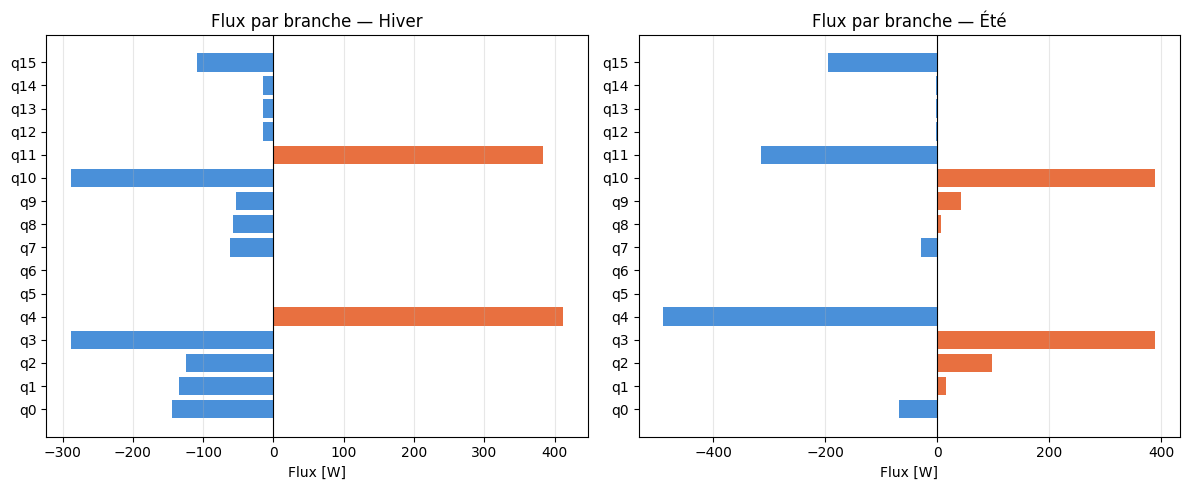


Figure sauvegardée : flux_branches.png


In [30]:
## ============================================================
## SECTION 8 — Charge Thermique en Régime Permanent
## Smart Cities — Modélisation Thermique
## ============================================================
## Prérequis : avoir exécuté les sections 6 et 7 avant ce bloc
## (variables A, G_hiver, G_ete, b_hiver, b_ete, f_hiver, f_ete
##  et theta_hiver, theta_ete doivent être en mémoire)
## ============================================================

print("=" * 55)
print("SECTION 8 — Charge thermique en régime permanent")
print("=" * 55)

# ── Rappel du principe ───────────────────────────────────────────
# Le contrôleur (branches q4 et q11) impose T_sp en injectant
# une puissance Q_CVC dans les nœuds θ2 (P1) et θ5 (P2).
# On calcule Q_CVC comme le flux traversant les branches contrôleur :
#
#   q_i = G_i * (b_i - θ_noeud)
#
# En hiver  : Q_CVC > 0  → chauffage nécessaire
# En été    : Q_CVC < 0  → climatisation nécessaire

def compute_thermal_load(A, G, b, f, theta, season=''):
    """
    Calcule la charge thermique du système CVC en régime permanent.

    La charge est obtenue via les flux traversant les branches
    contrôleur (q4 et q11) : q_i = G_i * (-A @ theta + b).
    Convention : Q > 0 = chauffage, Q < 0 = climatisation.

    Parameters
    ----------
    A : np.ndarray (16, 8)
        Matrice d'incidence du circuit thermique.
    G : np.ndarray (16, 16)
        Matrice diagonale des conductances [W/K].
    b : np.ndarray (16,)
        Vecteur des sources de température [°C].
    f : np.ndarray (8,)
        Vecteur des sources de flux [W].
    theta : np.ndarray (8,)
        Températures nodales en régime permanent [°C].
    season : str
        Label affiché dans les résultats ('HIVER' ou 'ÉTÉ').

    Returns
    -------
    Q_P1 : float
        Charge thermique pièce 1 via contrôleur q4 [W].
    Q_P2 : float
        Charge thermique pièce 2 via contrôleur q11 [W].
    Q_tot : float
        Charge thermique totale Q_P1 + Q_P2 [W].
    """
    # Flux sur chaque branche
    q_branches = np.diag(G) * (-A @ theta + b)

    print(f"\n── Flux par branche — {season} [W] ──")
    branch_names = [
        'q0  conv ext Sud', 'q1  cond Sud', 'q2  conv int Sud',
        'q3  Window adv P1', 'q4  Contrôleur P1',
        'q5  Wall (refend)', 'q6  Door int adv',
        'q7  conv ext Est', 'q8  cond Est', 'q9  conv int Est',
        'q10 Window adv P2', 'q11 Contrôleur P2',
        'q12 conv porte P2', 'q13 cond porte ext',
        'q14 conv porte hall', 'q15 Door ext adv'
    ]
    for name, q in zip(branch_names, q_branches):
        marker = " ◄ CVC" if 'Contrôleur' in name else ""
        print(f"  {name:<22s} = {q:+9.2f} W{marker}")

    # Charge thermique = flux des branches contrôleur
    Q_P1  = q_branches[4]   # q4  contrôleur pièce 1
    Q_P2  = q_branches[11]  # q11 contrôleur pièce 2
    Q_tot = Q_P1 + Q_P2

    print(f"\n── Charge thermique — {season} ──")
    print(f"  Q_CVC pièce 1 (q4)  = {Q_P1:+.2f} W")
    print(f"  Q_CVC pièce 2 (q11) = {Q_P2:+.2f} W")
    print(f"  Q_CVC total         = {Q_tot:+.2f} W")

    if Q_tot > 0:
        print(f"  → Besoin de CHAUFFAGE : {Q_tot:.2f} W")
    else:
        print(f"  → Besoin de CLIMATISATION : {abs(Q_tot):.2f} W")

    # Vérification : bilan nodal sur θ2 et θ5
    # Somme des flux entrant = 0 en régime permanent
    print(f"\n── Vérification bilan nodal ──")
    bilan_theta2 = sum(q_branches[i] * A[i, 2] for i in range(16))
    bilan_theta5 = sum(q_branches[i] * A[i, 5] for i in range(16))
    bilan_theta2 += f[2]  # apport flux nœud θ2
    bilan_theta5 += f[5]  # apport flux nœud θ5
    print(f"  Bilan θ2 (air P1) = {bilan_theta2:.4f} W  "
          f"{'✅' if abs(bilan_theta2) < 0.1 else '❌'}")
    print(f"  Bilan θ5 (air P2) = {bilan_theta5:.4f} W  "
          f"{'✅' if abs(bilan_theta5) < 0.1 else '❌'}")

    return Q_P1, Q_P2, Q_tot

Q_ch_P1, Q_ch_P2, Q_ch_tot = compute_thermal_load(
    A, G_hiver, b_hiver, f_hiver, theta_hiver, 'HIVER')
Q_cl_P1, Q_cl_P2, Q_cl_tot = compute_thermal_load(
    A, G_ete, b_ete, f_ete, theta_ete, 'ÉTÉ')

# ── Résumé ───────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("RÉSUMÉ — Charges thermiques nominales")
print("=" * 55)
S_hab = 2 * 30.0   # 60 m² surface habitable totale

print(f"\n  Chauffage (hiver, T_ext=3°C)  :")
print(f"    Q_ch = {Q_ch_tot:.1f} W  "
      f"({Q_ch_tot/S_hab:.1f} W/m²)")

print(f"\n  Climatisation (été, T_ext=25°C) :")
print(f"    Q_cl = {abs(Q_cl_tot):.1f} W  "
      f"({abs(Q_cl_tot)/S_hab:.1f} W/m²)")

# ── Visualisation ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphe 1 : flux par branche hiver
q_hiver = np.diag(G_hiver) * (-A @ theta_hiver + b_hiver)
q_ete   = np.diag(G_ete)   * (-A @ theta_ete   + b_ete)
branch_labels = [f"q{i}" for i in range(16)]
colors_h = ['#E87040' if q > 0 else '#4A90D9' for q in q_hiver]
colors_e = ['#E87040' if q > 0 else '#4A90D9' for q in q_ete]

axes[0].barh(branch_labels, q_hiver, color=colors_h)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_xlabel('Flux [W]')
axes[0].set_title('Flux par branche — Hiver')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(branch_labels, q_ete, color=colors_e)
axes[1].axvline(0, color='black', lw=0.8)
axes[1].set_xlabel('Flux [W]')
axes[1].set_title('Flux par branche — Été')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('flux_branches.png', dpi=150)
plt.show()
print("\nFigure sauvegardée : flux_branches.png")

SECTION 9 — Consommation Énergétique Annuelle

── Métadonnées station météo ──
  Ville     : LYON
  Pays      : FRA
  Latitude  : 45.73°
  Longitude : 5.08°
  Altitude  : 240.0 m
  Données   : 8760 heures (365 jours)

  T_ext min = -8.5°C
  T_ext max = 33.6°C
  T_ext moy = 11.9°C

── Degrés-Jours Unifiés — Lyon (EPW IWEC) ──
  DJU chauffage (base 19.0°C) = 2618 K·j
  DJU climatisation (base 23.0°C) = 32 K·j

── Conductances globales bâtiment ──
  G_bât hiver = 73.66 W/K
  G_bât été   = 250.66 W/K

── Consommation énergétique annuelle ──
  Chauffage   : 4628.1 kWh/an  (77.1 kWh/m²·an)
  Climatisation: 189.7 kWh/an  (3.2 kWh/m²·an)
  TOTAL        : 4817.8 kWh/an  (80.3 kWh/m²·an)

── Approche intégration horaire (plus précise) ──
  Chauffage   : 5140.7 kWh/an  (85.7 kWh/m²·an)
  Climatisation: 651.8 kWh/an  (10.9 kWh/m²·an)
  TOTAL        : 5792.5 kWh/an  (96.5 kWh/m²·an)

RÉSUMÉ — Consommation spécifique annuelle (Lyon)
  Méthode DJU          : 80.3 kWh/m²·an
  Intégration horaire  : 96

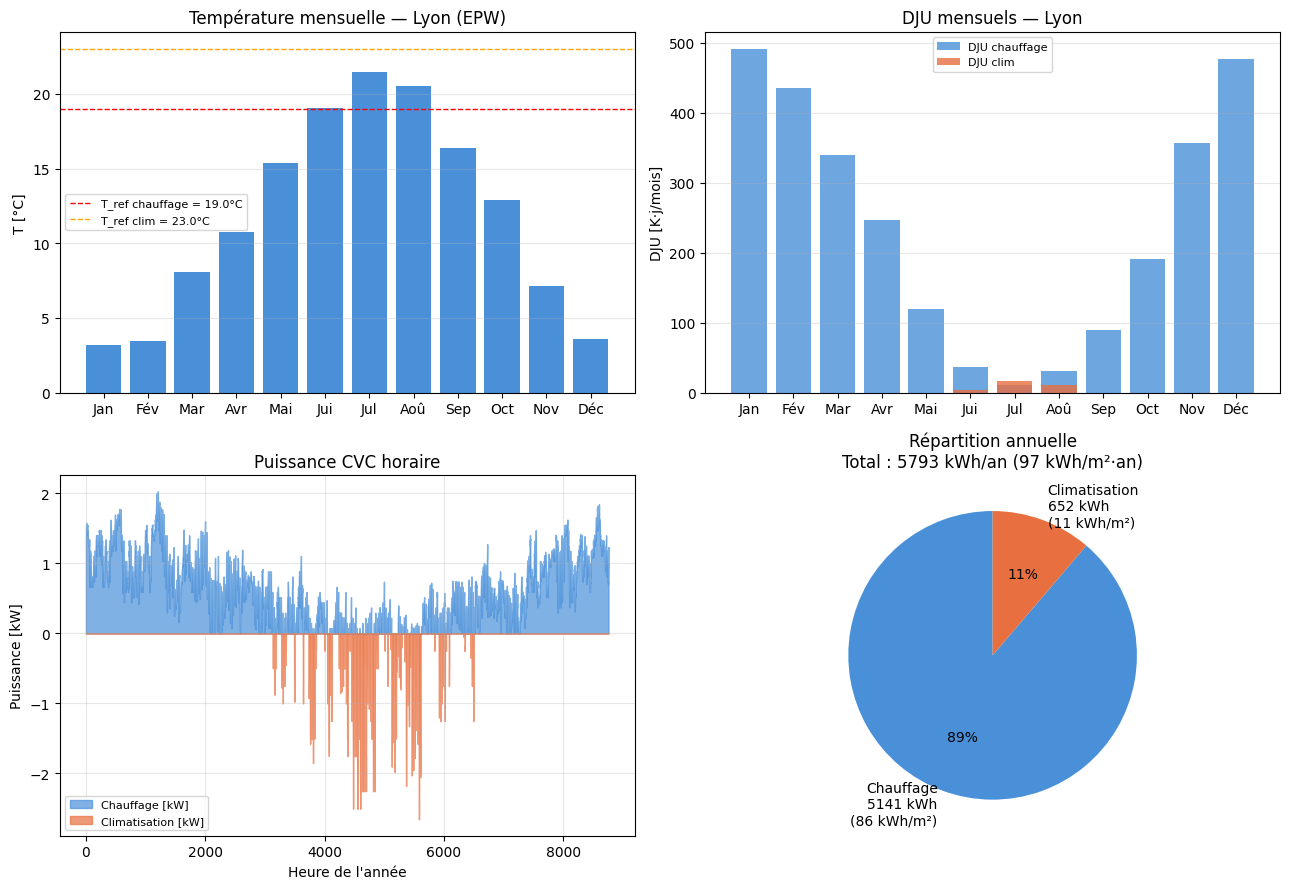

Figure sauvegardée : consommation_annuelle.png


In [31]:
## ============================================================
## SECTION 9 — Consommation Énergétique Annuelle
## Smart Cities — Modélisation Thermique
##
## Utilise le fichier météo EPW de Lyon (IWEC) et dm4bem.py
## Prérequis : sections 6, 7 et 8 déjà exécutées
## (G_bat_hiver, G_bat_ete, theta_hiver, theta_ete en mémoire)
## ============================================================

import sys
import os

# Après upload, dm4bem.py est dans /content/
# Ajoutez le chemin pour pouvoir l'importer
if '/content' not in sys.path:
    sys.path.insert(0, '/content')

import dm4bem   # import de la librairie du prof

EPW_FILE = '/content/drive/MyDrive/SmartCities/FRA_Lyon.074810_IWEC.epw'

## ============================================================
print("=" * 55)
print("SECTION 9 — Consommation Énergétique Annuelle")
print("=" * 55)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. LECTURE DU FICHIER MÉTÉO EPW ─────────────────────────────
weather_data, metadata = dm4bem.read_epw(EPW_FILE, coerce_year=2000)

print(f"\n── Métadonnées station météo ──")
print(f"  Ville     : {metadata['city']}")
print(f"  Pays      : {metadata['country']}")
print(f"  Latitude  : {metadata['latitude']}°")
print(f"  Longitude : {metadata['longitude']}°")
print(f"  Altitude  : {metadata['altitude']} m")
print(f"  Données   : {len(weather_data)} heures ({len(weather_data)//24} jours)")

# Température extérieure horaire
T_ext_h = weather_data['temp_air'].copy()
T_ext_h.index = T_ext_h.index.tz_localize(None)  # fix timezone

print(f"\n  T_ext min = {T_ext_h.min():.1f}°C")
print(f"  T_ext max = {T_ext_h.max():.1f}°C")
print(f"  T_ext moy = {T_ext_h.mean():.1f}°C")

# ── 2. CALCUL DES DEGRÉS-JOURS ───────────────────────────────────
# Méthode météo simple (base 18°C pour chauffage, base 26°C clim)
# DJU_ch [K·j] = Σ max(T_ref_ch - T_ext_jour, 0) sur la saison
# DJU_cl [K·j] = Σ max(T_ext_jour - T_ref_cl, 0) sur la saison

T_ref_ch = 19.0
T_ref_cl = 23.0

# Température moyenne journalière
T_ext_daily = T_ext_h.resample('D').mean()

# DJU chauffage (1er oct → 20 mai = jours 274 → 141)
mask_ch = (T_ext_daily.index.dayofyear >= 274) | \
          (T_ext_daily.index.dayofyear <= 141)
DJU_ch = np.sum(np.maximum(T_ref_ch - T_ext_daily[mask_ch], 0))

# DJU climatisation (21 mai → 30 sept = jours 142 → 273)
mask_cl = (T_ext_daily.index.dayofyear >= 142) & \
          (T_ext_daily.index.dayofyear <= 273)
DJU_cl = np.sum(np.maximum(T_ext_daily[mask_cl] - T_ref_cl, 0))

print(f"\n── Degrés-Jours Unifiés — Lyon (EPW IWEC) ──")
print(f"  DJU chauffage (base {T_ref_ch}°C) = {DJU_ch:.0f} K·j")
print(f"  DJU climatisation (base {T_ref_cl}°C) = {DJU_cl:.0f} K·j")

# ── 3. CONSOMMATION ANNUELLE PAR MÉTHODE DJU ─────────────────────
# E = G_bât × DJU × 24  [Wh]
# avec G_bât en W/K calculé en section 6

# Conductance globale du bâtiment (depuis section 6)
# (recalculée ici pour être autonome)
hi, he = 8.0, 25.0
lambda_b, lambda_ldv = 1.70, 0.04
e_beton, e_ldv = 0.24, 0.16
e_ref = 0.20
A_sud = 36.0; A_est = 15.4; A_ref = 13.0
R_cond_ext = e_beton/lambda_b + e_ldv/lambda_ldv
U_mur = 1/(1/he + R_cond_ext + 1/hi)
U_ref = 1/(1/hi + e_ref/lambda_b + 1/hi)
G_flow_h = 18.0; G_flow_e = 195.0

G_bat_hiver = U_mur*2*A_sud + U_mur*A_est + U_ref*A_ref + G_flow_h
G_bat_ete   = U_mur*2*A_sud + U_mur*A_est + U_ref*A_ref + G_flow_e

print(f"\n── Conductances globales bâtiment ──")
print(f"  G_bât hiver = {G_bat_hiver:.2f} W/K")
print(f"  G_bât été   = {G_bat_ete:.2f} W/K")

# Énergie annuelle [Wh]
E_ch_Wh = G_bat_hiver * DJU_ch * 24   # Wh
E_cl_Wh = G_bat_ete   * DJU_cl * 24   # Wh
E_tot_Wh = E_ch_Wh + E_cl_Wh

# Conversion en kWh
E_ch_kWh  = E_ch_Wh  / 1000
E_cl_kWh  = E_cl_Wh  / 1000
E_tot_kWh = E_tot_Wh / 1000

# Surface habitable
S_hab = 2 * 30.0   # 60 m²

# Consommation spécifique [kWh/m²·an]
e_ch  = E_ch_kWh  / S_hab
e_cl  = E_cl_kWh  / S_hab
e_tot = E_tot_kWh / S_hab

print(f"\n── Consommation énergétique annuelle ──")
print(f"  Chauffage   : {E_ch_kWh:.1f} kWh/an  ({e_ch:.1f} kWh/m²·an)")
print(f"  Climatisation: {E_cl_kWh:.1f} kWh/an  ({e_cl:.1f} kWh/m²·an)")
print(f"  TOTAL        : {E_tot_kWh:.1f} kWh/an  ({e_tot:.1f} kWh/m²·an)")

# ── 4. APPROCHE ALTERNATIVE — intégration horaire directe ────────
# Plus précise que les DJU : on intègre G_bât × ΔT heure par heure

T_sp_h = 19.0   # °C consigne hiver
T_sp_e = 23.0   # °C consigne été

# Heures de chauffage : T_ext < T_sp_h
mask_ch_h = T_ext_h < T_sp_h
Q_ch_h = G_bat_hiver * np.maximum(T_sp_h - T_ext_h[mask_ch_h], 0)
E_ch_int_kWh = Q_ch_h.sum() / 1000   # Wh → kWh

# Heures de climatisation : T_ext > T_sp_e
mask_cl_h = T_ext_h > T_sp_e
Q_cl_h = G_bat_ete * np.maximum(T_ext_h[mask_cl_h] - T_sp_e, 0)
E_cl_int_kWh = Q_cl_h.sum() / 1000

E_tot_int_kWh = E_ch_int_kWh + E_cl_int_kWh

print(f"\n── Approche intégration horaire (plus précise) ──")
print(f"  Chauffage   : {E_ch_int_kWh:.1f} kWh/an  "
      f"({E_ch_int_kWh/S_hab:.1f} kWh/m²·an)")
print(f"  Climatisation: {E_cl_int_kWh:.1f} kWh/an  "
      f"({E_cl_int_kWh/S_hab:.1f} kWh/m²·an)")
print(f"  TOTAL        : {E_tot_int_kWh:.1f} kWh/an  "
      f"({E_tot_int_kWh/S_hab:.1f} kWh/m²·an)")

# ── 5. RÉSUMÉ ────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"RÉSUMÉ — Consommation spécifique annuelle (Lyon)")
print(f"{'='*55}")
print(f"  Méthode DJU          : {e_tot:.1f} kWh/m²·an")
print(f"  Intégration horaire  : {E_tot_int_kWh/S_hab:.1f} kWh/m²·an")

# ── 6. VISUALISATIONS ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Température extérieure mensuelle
T_monthly = T_ext_h.resample('ME').mean()
months = ['Jan','Fév','Mar','Avr','Mai','Jui',
          'Jul','Aoû','Sep','Oct','Nov','Déc']
axes[0,0].bar(range(12), T_monthly.values, color='#4A90D9')
axes[0,0].axhline(T_ref_ch, color='red', ls='--', lw=1,
                  label=f'T_ref chauffage = {T_ref_ch}°C')
axes[0,0].axhline(T_ref_cl, color='orange', ls='--', lw=1,
                  label=f'T_ref clim = {T_ref_cl}°C')
axes[0,0].set_xticks(range(12)); axes[0,0].set_xticklabels(months)
axes[0,0].set_ylabel('T [°C]')
axes[0,0].set_title('Température mensuelle — Lyon (EPW)')
axes[0,0].legend(fontsize=8); axes[0,0].grid(axis='y', alpha=0.3)

# (b) DJU mensuels
DJU_ch_monthly = T_ext_daily.resample('ME').apply(
    lambda x: np.sum(np.maximum(T_ref_ch - x, 0)))
DJU_cl_monthly = T_ext_daily.resample('ME').apply(
    lambda x: np.sum(np.maximum(x - T_ref_cl, 0)))
axes[0,1].bar(range(12), DJU_ch_monthly.values,
              label='DJU chauffage', color='#4A90D9', alpha=0.8)
axes[0,1].bar(range(12), DJU_cl_monthly.values,
              label='DJU clim', color='#E87040', alpha=0.8)
axes[0,1].set_xticks(range(12)); axes[0,1].set_xticklabels(months)
axes[0,1].set_ylabel('DJU [K·j/mois]')
axes[0,1].set_title('DJU mensuels — Lyon')
axes[0,1].legend(fontsize=8); axes[0,1].grid(axis='y', alpha=0.3)

# (c) Puissance horaire sur l'année
axes[1,0].fill_between(range(len(T_ext_h)),
    G_bat_hiver * np.maximum(T_sp_h - T_ext_h, 0) / 1000,
    alpha=0.7, color='#4A90D9', label='Chauffage [kW]')
axes[1,0].fill_between(range(len(T_ext_h)),
    -G_bat_ete * np.maximum(T_ext_h - T_sp_e, 0) / 1000,
    alpha=0.7, color='#E87040', label='Climatisation [kW]')
axes[1,0].set_xlabel('Heure de l\'année')
axes[1,0].set_ylabel('Puissance [kW]')
axes[1,0].set_title('Puissance CVC horaire')
axes[1,0].legend(fontsize=8); axes[1,0].grid(alpha=0.3)

# (d) Bilan annuel en camembert
labels_pie = [f'Chauffage\n{E_ch_int_kWh:.0f} kWh\n({E_ch_int_kWh/S_hab:.0f} kWh/m²)',
              f'Climatisation\n{E_cl_int_kWh:.0f} kWh\n({E_cl_int_kWh/S_hab:.0f} kWh/m²)']
colors_pie = ['#4A90D9', '#E87040']
axes[1,1].pie([E_ch_int_kWh, E_cl_int_kWh],
              labels=labels_pie, colors=colors_pie,
              autopct='%1.0f%%', startangle=90)
axes[1,1].set_title(f'Répartition annuelle\nTotal : '
                    f'{E_tot_int_kWh:.0f} kWh/an '
                    f'({E_tot_int_kWh/S_hab:.0f} kWh/m²·an)')

plt.tight_layout()
plt.savefig('consommation_annuelle.png', dpi=150)
plt.show()
print("Figure sauvegardée : consommation_annuelle.png")

In [32]:
# ── FONCTIONS EULER ───────────────────────────────────────────────
def euler_explicit(As, Bs, u, dt, n, theta0=None,
                   controller='perfect', Tisp=19.0, Kpp=500.0):
    """
    Intègre le système d'état par la méthode d'Euler explicite.

    Parameters
    ----------
    As : np.ndarray
        Matrice d'état du système.
    Bs : np.ndarray
        Matrice d'entrée du système.
    u : np.ndarray (n_u, n)
        Vecteur d'entrée en temps.
    dt : float
        Pas de temps [s].
    n : int
        Nombre de pas de temps.
    theta0 : np.ndarray, optional
        Conditions initiales. Zéro par défaut.
    controller : str
        Type de contrôleur :
        'perfect'  → Kp fixe (défaut)
        'heating'  → chauffage uniquement (Q=0 si θ > Tisp)
        'cooling'  → climatisation uniquement (Q=0 si θ < Tisp)
        'deadband' → zone morte ±2°C autour de Tisp
    Tisp : float
        Consigne de température intérieure [°C].
    Kpp : float
        Gain du contrôleur proportionnel [W/K].

    Returns
    -------
    th : np.ndarray (nc, n)
        Évolution temporelle des températures nodales [°C].
    """
    nc = As.shape[0]
    th = np.zeros((nc, n))
    th[:,0] = theta0 if theta0 is not None else np.zeros(nc)

    # index de θ_air P1 et P2 dans idx_C
    i_P1 = np.where(idx_C == 4)[0][0]
    i_P2 = np.where(idx_C == 8)[0][0]
    # index de T_sp dans u (colonne 1)
    i_Tsp = 1

    for k in range(n-1):

        if controller == 'heating':
            theta_P1 = th[i_P1, k]
            theta_P2 = th[i_P2, k]
            # Si les deux pièces sont au-dessus de la consigne → éteindre
            if theta_P1 >= Tisp and theta_P2 >= Tisp:
                u[1, k] = theta_P1  # T_sp = température actuelle → Q=0
            else:
                u[1, k] = Tisp  # consigne active

        elif controller == 'cooling':
            Tisp_c = 23.0
            delta = 2.0
            theta_P1 = th[i_P1, k]
            theta_P2 = th[i_P2, k]
            if theta_P1 <= Tisp_c + delta:
                u[3, k] = 0
            else:
                u[3, k] = Kpp * (Tisp_c - theta_P1)
            if theta_P2 <= Tisp_c + delta:
                u[3, k] = 0
            else:
                u[3, k] = Kpp * (Tisp_c - theta_P2)

        elif controller == 'deadband':
            delta = 2.0
            theta_P2 = th[i_P2, k]
            if Tisp - delta <= theta_P2 <= Tisp + delta:
                u[3, k] = 0
            else:
                u[3, k] = Kpp * (Tisp - theta_P2)

        nxt = th[:,k] + dt*(As@th[:,k] + Bs@u[:,k])
        if np.any(np.abs(nxt) > 1e8):
            print(f"  ⚠️  Divergence k={k}")
            th[:,k+1:] = np.nan; break
        th[:,k+1] = nxt
    return th




def euler_implicit(As, Bs, u, dt, n, theta0=None):
    nc = As.shape[0]
    th = np.zeros((nc, n))
    th[:,0] = theta0 if theta0 is not None else np.zeros(nc)
    M = np.linalg.inv(np.eye(nc) - dt*As)
    for k in range(n-1):
        th[:,k+1] = M @ (th[:,k] + dt*Bs@u[:,k])  # ← u[:,k] corrigé
    return th

def build_Bs(Kp=1e3, season='hiver'):
    G_vec = make_G_vec(season, Kp=Kp)
    G_mat = np.diag(G_vec)
    AtGA  = A.T @ G_mat @ A
    Kcc_  = AtGA[np.ix_(idx_C,idx_C)]
    Kc0_  = AtGA[np.ix_(idx_C,idx_0)]
    K00_  = AtGA[np.ix_(idx_0,idx_0)]
    K00i_ = np.linalg.inv(K00_)
    Keff_ = Kcc_ - Kc0_ @ K00i_ @ AtGA[np.ix_(idx_0,idx_C)]
    As_   = -np.diag(1.0/C_C) @ Keff_

    n_u = 4
    Bs_ = np.zeros((len(idx_C), n_u))
    for j,(dTe,dTs,dTh,dQ) in enumerate([(1,0,0,0),(0,1,0,0),(0,0,1,0),(0,0,0,1)]):
        db = np.zeros(25)
        db[[0,5,12,17]] += dTe
        db[[6,18]]      += dTs
        db[[23,24]]     += dTh
        df = np.zeros(17); df[8] += dQ
        rhs   = A.T @ G_mat @ db + df
        rhs_C = rhs[idx_C] - Kc0_ @ K00i_ @ rhs[idx_0]
        Bs_[:,j] = (1.0/C_C) * rhs_C
    return As_, Bs_

print("✅ Fonctions Euler et build_Bs définies")

✅ Fonctions Euler et build_Bs définies


SECTION 10 — Modèle Dynamique

── Capacités [J/K] ──
  θ 1 c0 béton Sud = 17487360 J/K (4857.6 Wh/K)
  θ 4 c1 air P1 = 108648 J/K (30.2 Wh/K)
  θ 6 c2 refend = 5262400 J/K (1461.8 Wh/K)
  θ 8 c4 air P2 = 108648 J/K (30.2 Wh/K)
  θ11 c3 béton Est = 7480704 J/K (2078.0 Wh/K)
  θ15 c5 hall = 7480704 J/K (2078.0 Wh/K)

── Valeurs propres As (Kp=500) ──
  λ0 =    -0.006225 s⁻¹  (τ = 0.04 h)
  λ1 =    -0.005616 s⁻¹  (τ = 0.05 h)
  λ2 =    -0.000028 s⁻¹  (τ = 10.03 h)
  λ3 =    -0.000024 s⁻¹  (τ = 11.65 h)
  λ4 =    -0.000012 s⁻¹  (τ = 23.47 h)
  λ5 =    -0.000005 s⁻¹  (τ = 52.86 h)

── Pas de temps ──
  Δt_max  = 321.3 s  (5.4 min)
  dt      = 300 s  (0.083 h)
  t_stab  = 211.4 h

── Réponse indicielle (2545 pas, dt=300s) ──


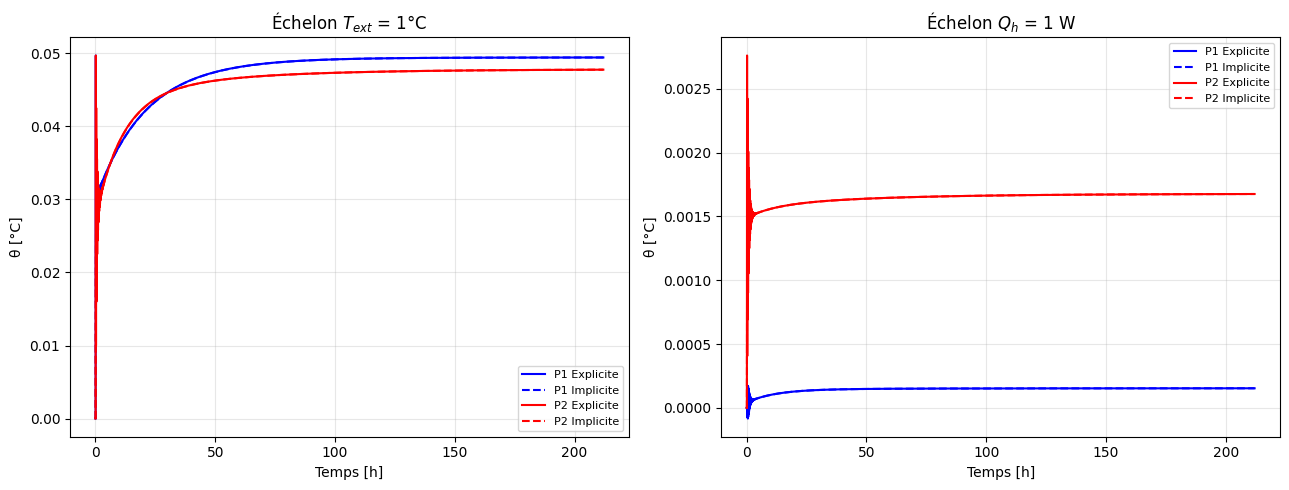


Simulation EPW — Lyon 10 avril → 15 mai 2000
  Kp=500 | Δt=300s | 10357 pas | 36.0 jours
  CI air P1=18.20°C  air P2=18.15°C
  Euler explicite...
  Euler implicite...


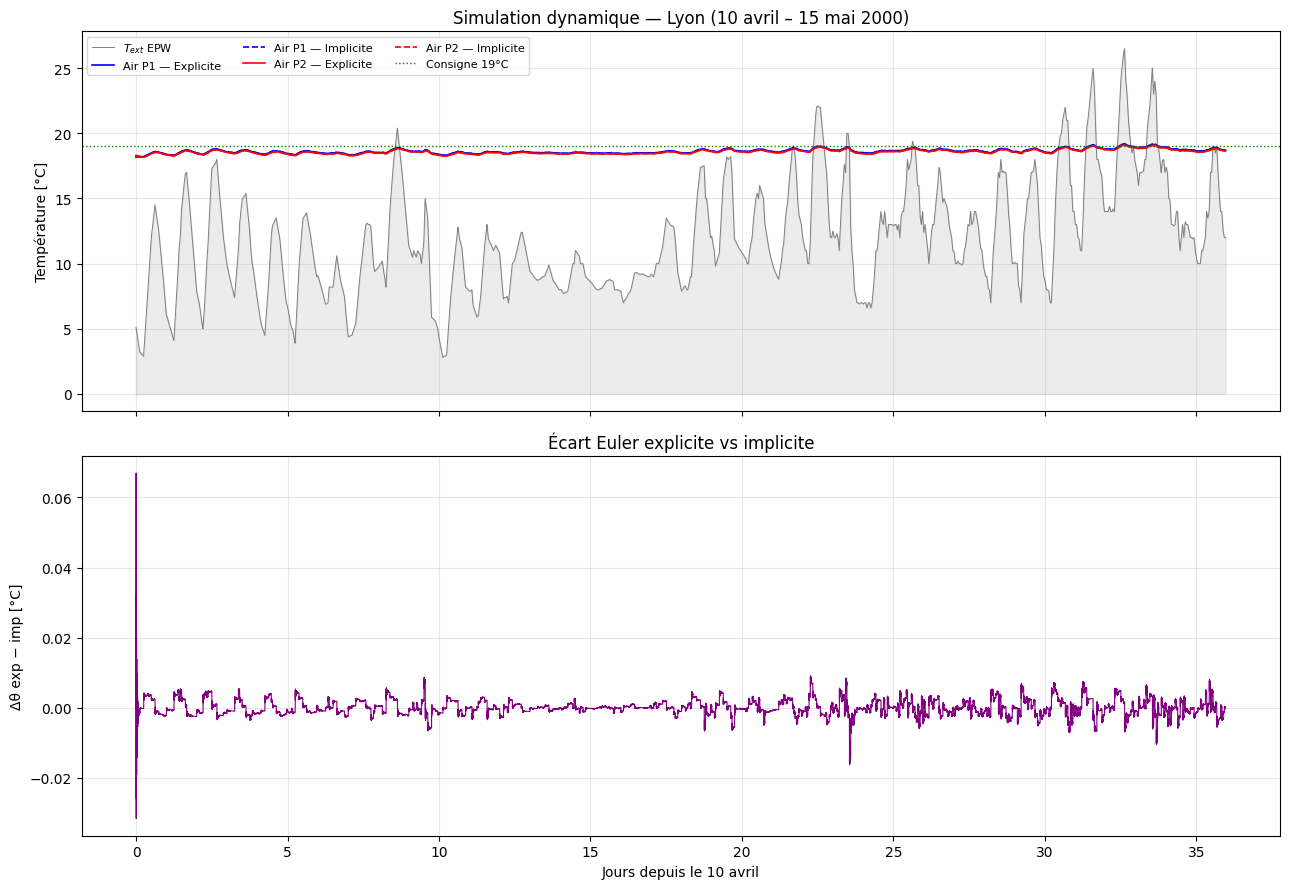


── Résumé ──
  Air P1 : 18.2→19.2°C
  Air P2 : 18.2→19.1°C
  Écart max exp/imp : 0.0669°C

CONTRÔLEURS NON-LINÉAIRES

── Contrôleur : perfect ──
  Air P1 : 18.2→19.2°C
  Air P2 : 18.2→19.1°C


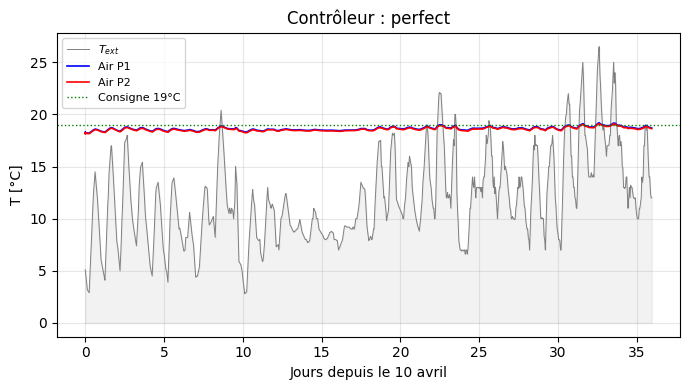

  ✅ controleur_perfect.png sauvegardé

── Contrôleur : heating ──
  Air P1 : 18.2→20.3°C
  Air P2 : 18.2→20.1°C


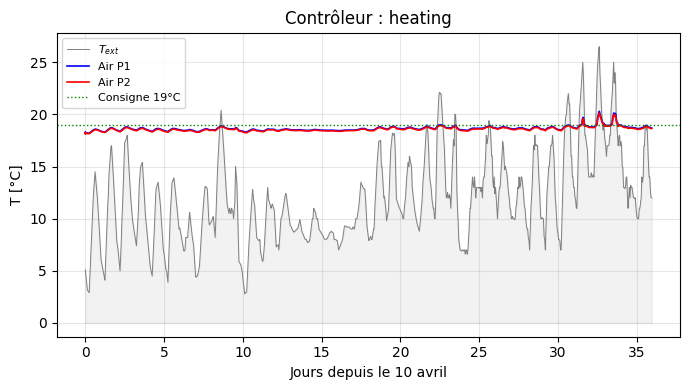

  ✅ controleur_heating.png sauvegardé

── Contrôleur : cooling ──
  Air P1 : 18.2→19.2°C
  Air P2 : 18.0→19.0°C


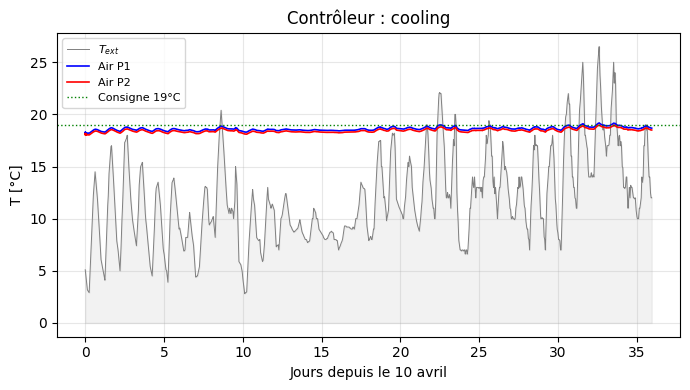

  ✅ controleur_cooling.png sauvegardé

── Contrôleur : deadband ──
  Air P1 : 18.2→19.2°C
  Air P2 : 18.0→19.0°C


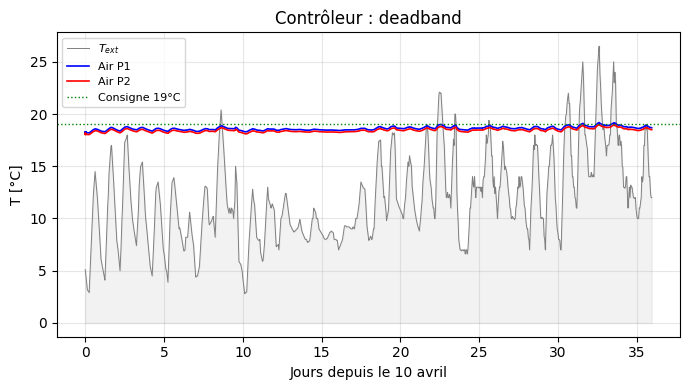

  ✅ controleur_deadband.png sauvegardé


In [33]:
## ============================================================
## SECTION 10 — Modèle Dynamique — State-space correct
## Suit la méthode dm4bem : tc2ss avec contrôleur séparé
## ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

print("=" * 60)
print("SECTION 10 — Modèle Dynamique")
print("=" * 60)

# ── PARAMÈTRES (repris des sections précédentes) ─────────────────
hi, he = 8.0, 25.0
lambda_b, lambda_ldv = 1.70, 0.04
rho_b, cp_b = 2300.0, 880.0
rho_a, cp_a = 1.2, 1006.0

e_beton_ext = 0.24; e_ldv_ext = 0.16
e_beton_ref = 0.10; e_beton_hal = 0.24

A_sud=36.0; A_sud2=36.0; A_ref=13.0; A_hal=15.4; A_prt=2.0; V_air=90.0
G_flow_h=18.0; G_flow_e=195.0

# ── CONDUCTANCES SANS CONTRÔLEUR ────────────────────────────────


def make_G_vec(season='hiver', Kp=0):
    Gf = G_flow_h if season == 'hiver' else G_flow_e
    return np.array([
        he*A_sud,                          # q0
        (lambda_b/e_beton_ext)*A_sud,      # q1
        (lambda_b/e_beton_ext)*A_sud,      # q2
        (lambda_ldv/e_ldv_ext)*A_sud,      # q3
        hi*A_sud,                          # q4
        Gf,                                # q5  adv fen P1
        Kp,                                # q6  ctrl P1 ← Kp paramètre
        hi*A_ref,                          # q7
        (lambda_b/e_beton_ref)*A_ref,      # q8
        (lambda_b/e_beton_ref)*A_ref,      # q9
        hi*A_ref,                          # q10
        Gf,                                # q11 adv porte P1↔P2
        he*A_sud,                          # q12
        (lambda_b/e_beton_ext)*A_sud,      # q13
        (lambda_b/e_beton_ext)*A_sud,      # q14
        (lambda_ldv/e_ldv_ext)*A_sud,      # q15
        hi*A_sud,                          # q16
        Gf,                                # q17 adv fen P2
        Kp,                                # q18 ctrl P2 ← Kp paramètre
        hi*A_hal,                          # q19
        (lambda_b/e_beton_hal)*A_hal,      # q20
        (lambda_b/e_beton_hal)*A_hal,      # q21
        (lambda_ldv/e_ldv_ext)*A_hal,      # q22
        he*A_hal,                          # q23
        Gf,                                # q24 adv porte hall
    ])

# Matrice A (25×17)
A = np.array([
 [ 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q0
 [-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q1
 [ 0,-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q2
 [ 0, 0,-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q3
 [ 0, 0, 0,-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q4
 [ 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q5 T_ext→θ4
 [ 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q6 T_sp→θ4
 [ 0, 0, 0, 0,-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q7
 [ 0, 0, 0, 0, 0,-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q8
 [ 0, 0, 0, 0, 0, 0,-1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],  # q9
 [ 0, 0, 0, 0, 0, 0, 0,-1, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # q10
 [ 0, 0, 0, 0,-1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # q11 θ4↔θ8
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],  # q12
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,-1, 0, 0, 0, 0],  # q13
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,-1, 0, 0, 0, 0, 0],  # q14
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,-1, 0, 0, 0, 0, 0, 0],  # q15
 [ 0, 0, 0, 0, 0, 0, 0, 0, 1,-1, 0, 0, 0, 0, 0, 0, 0],  # q16
 [ 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # q17 T_ext→θ8
 [ 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # q18 T_sp→θ8
 [ 0, 0, 0, 0, 0, 0, 0, 0,-1, 0, 0, 0, 0, 1, 0, 0, 0],  # q19
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,-1, 0, 0],  # q20 θ14→θ13
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,-1, 0],  # q21 θ15→θ14
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,-1],  # q22 θ16→θ15
 [ 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],  # q23 T_hall→θ16
 [ 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],  # q24 T_hall→θ8
 ], dtype=float)

# Capacités (béton uniquement)
C_diag = np.zeros(17)
C_diag[1]  = rho_b*cp_b*e_beton_ext*A_sud     # c0 béton Sud
C_diag[4]  = rho_a*cp_a*V_air                  # c1 air P1
C_diag[6]  = rho_b*cp_b*(2*e_beton_ref)*A_ref  # c2 béton refend
C_diag[8]  = rho_a*cp_a*V_air                  # c4 air P2
C_diag[11] = rho_b*cp_b*e_beton_ext*A_est      # c3 béton Est
C_diag[15] = rho_b*cp_b*e_beton_hal*A_hal      # c5 béton hall

print("\n── Capacités [J/K] ──")
for i,n in {1:'c0 béton Sud',4:'c1 air P1',6:'c2 refend',
             8:'c4 air P2',11:'c3 béton Est',15:'c5 hall'}.items():
    print(f"  θ{i:2d} {n} = {C_diag[i]:.0f} J/K ({C_diag[i]/3600:.1f} Wh/K)")

idx_C = np.where(C_diag != 0)[0]
idx_0 = np.where(C_diag == 0)[0]
C_C   = C_diag[idx_C]
n_u   = 4


# ── STATE-SPACE AVEC Kp=500 (cohérent As + Bs) ──────────────────
Kp_final = 500   # bon compromis stabilité/contrôle

As, Bs = build_Bs(Kp=Kp_final)

print("\n── Valeurs propres As (Kp=500) ──")
eigs = np.sort(np.real(np.linalg.eigvals(As)))
for i,lam in enumerate(eigs):
    tau = abs(1/lam)/3600 if abs(lam)>1e-12 else float('inf')
    print(f"  λ{i} = {lam:12.6f} s⁻¹  (τ = {tau:.2f} h)")

lam_max = np.max(np.abs(eigs[eigs < -1e-12]))
lam_min = np.min(np.abs(eigs[eigs < -1e-12]))
dt_max  = 2.0 / lam_max
t_stab  = 4 * (1.0/lam_min)

candidates = [1,10,60,300,600,1800,3600,7200,14400,21600]
valid = [d for d in candidates if d < dt_max]
dt = float(valid[-1]) if valid else 1.0

print(f"\n── Pas de temps ──")
print(f"  Δt_max  = {dt_max:.1f} s  ({dt_max/60:.1f} min)")
print(f"  dt      = {dt:.0f} s  ({dt/3600:.3f} h)")
print(f"  t_stab  = {t_stab/3600:.1f} h")

# ── RÉPONSE INDICIELLE ───────────────────────────────────────────
duration = np.ceil(t_stab/3600)*3600
n_step = int(duration/dt) + 1
t_h = np.arange(n_step)*dt/3600

i_P1 = np.where(idx_C==4)[0][0]
i_P2 = np.where(idx_C==8)[0][0]

u_Te = np.zeros((n_u, n_step)); u_Te[0, 1:] = 1.0
u_Qh = np.zeros((n_u, n_step)); u_Qh[3, 1:] = 1.0

print(f"\n── Réponse indicielle ({n_step} pas, dt={dt:.0f}s) ──")
th_exp_Te = euler_explicit(As, Bs, u_Te, dt, n_step)
th_imp_Te = euler_implicit(As, Bs, u_Te, dt, n_step)
th_exp_Qh = euler_explicit(As, Bs, u_Qh, dt, n_step)
th_imp_Qh = euler_implicit(As, Bs, u_Qh, dt, n_step)

fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax, exp, imp, title in zip(
    axes,
    [th_exp_Te, th_exp_Qh],
    [th_imp_Te, th_imp_Qh],
    ['Échelon $T_{ext}$ = 1°C','Échelon $Q_h$ = 1 W']
):
    ax.plot(t_h, exp[i_P1],'b-', lw=1.5, label='P1 Explicite')
    ax.plot(t_h, imp[i_P1],'b--',lw=1.5, label='P1 Implicite')
    ax.plot(t_h, exp[i_P2],'r-', lw=1.5, label='P2 Explicite')
    ax.plot(t_h, imp[i_P2],'r--',lw=1.5, label='P2 Implicite')
    ax.set_xlabel('Temps [h]'); ax.set_ylabel('θ [°C]')
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('reponse_indicielle.png', dpi=150)
plt.show()

# ── SIMULATION EPW ───────────────────────────────────────────────
print("\n" + "="*60)
print("Simulation EPW — Lyon 10 avril → 15 mai 2000")
print("="*60)

epw_file = '/content/drive/MyDrive/SmartCities/FRA_Lyon.074810_IWEC.epw'
weather_data, _ = dm4bem.read_epw(epw_file, coerce_year=2000)
weather_data.index = weather_data.index.tz_localize(None)
T_ext_epw = weather_data['temp_air']['2000-04-10':'2000-05-15']

tw    = np.arange(len(T_ext_epw))*3600.0
t_sim = np.arange(0, tw[-1]+dt, dt)
T_ext_s = np.interp(t_sim, tw, T_ext_epw.values)
n_sim = len(t_sim)

u_epw = np.zeros((n_u, n_sim))
u_epw[0,:] = T_ext_s
u_epw[1,:] = 19.0    # T_sp
u_epw[2,:] = 13.0    # T_hall
u_epw[3,:] = 80.0    # Q

# CI = régime permanent hiver
G_vec_ss = make_G_vec('hiver', Kp=Kp_final)
G_ss = np.diag(G_vec_ss)
b_ss = np.zeros(25)
b_ss[0]=3; b_ss[5]=3; b_ss[6]=19; b_ss[12]=3
b_ss[17]=3; b_ss[18]=19; b_ss[23]=13; b_ss[24]=13
f_ss = np.zeros(17); f_ss[8]=80
theta_ss = np.linalg.solve(A.T@G_ss@A, A.T@G_ss@b_ss+f_ss)
theta0_C = theta_ss[idx_C]

print(f"  Kp={Kp_final} | Δt={dt:.0f}s | {n_sim} pas | {n_sim*dt/3600/24:.1f} jours")
print(f"  CI air P1={theta0_C[i_P1]:.2f}°C  air P2={theta0_C[i_P2]:.2f}°C")

print("  Euler explicite...")
th_epw_exp = euler_explicit(As, Bs, u_epw, dt, n_sim, theta0=theta0_C)
print("  Euler implicite...")
th_epw_imp = euler_implicit(As, Bs, u_epw, dt, n_sim, theta0=theta0_C)

t_days = t_sim/3600/24
fig, axes = plt.subplots(2,1,figsize=(13,9),sharex=True)

axes[0].fill_between(t_days, T_ext_s, alpha=0.15, color='gray')
axes[0].plot(t_days, T_ext_s,'gray',lw=0.7,label='$T_{ext}$ EPW')
axes[0].plot(t_days, th_epw_exp[i_P1],'b-', lw=1.2, label='Air P1 — Explicite')
axes[0].plot(t_days, th_epw_imp[i_P1],'b--',lw=1.2, label='Air P1 — Implicite')
axes[0].plot(t_days, th_epw_exp[i_P2],'r-', lw=1.2, label='Air P2 — Explicite')
axes[0].plot(t_days, th_epw_imp[i_P2],'r--',lw=1.2, label='Air P2 — Implicite')
axes[0].axhline(19.0,color='green',ls=':',lw=1,label='Consigne 19°C')
axes[0].set_ylabel('Température [°C]')
axes[0].set_title('Simulation dynamique — Lyon (10 avril – 15 mai 2000)')
axes[0].legend(fontsize=8,ncol=3); axes[0].grid(alpha=0.3)

diff = th_epw_exp[i_P2] - th_epw_imp[i_P2]
axes[1].plot(t_days, diff,'purple',lw=0.8)
axes[1].set_ylabel('Δθ exp − imp [°C]')
axes[1].set_xlabel('Jours depuis le 10 avril')
axes[1].set_title('Écart Euler explicite vs implicite')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('simulation_epw.png', dpi=150)
plt.show()

print(f"\n── Résumé ──")
print(f"  Air P1 : {np.nanmin(th_epw_exp[i_P1]):.1f}→{np.nanmax(th_epw_exp[i_P1]):.1f}°C")
print(f"  Air P2 : {np.nanmin(th_epw_exp[i_P2]):.1f}→{np.nanmax(th_epw_exp[i_P2]):.1f}°C")
print(f"  Écart max exp/imp : {np.nanmax(np.abs(diff)):.4f}°C")

# ─────────────────────────────────────────────────────────────────
# CONTRÔLEURS NON-LINÉAIRES
# ─────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("CONTRÔLEURS NON-LINÉAIRES")
print("="*60)


for mode in ['perfect', 'heating', 'cooling', 'deadband']:
    print(f"\n── Contrôleur : {mode} ──")
    th = euler_explicit(As, Bs, u_epw.copy(), dt, n_sim,
                        theta0=theta0_C,
                        controller=mode, Tisp=19.0, Kpp=500.0)
    print(f"  Air P1 : {np.nanmin(th[i_P1]):.1f}→{np.nanmax(th[i_P1]):.1f}°C")
    print(f"  Air P2 : {np.nanmin(th[i_P2]):.1f}→{np.nanmax(th[i_P2]):.1f}°C")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.fill_between(t_days, T_ext_s, alpha=0.1, color='gray')
    ax.plot(t_days, T_ext_s, 'gray', lw=0.7, label='$T_{ext}$')
    ax.plot(t_days, th[i_P1], 'b-', lw=1.2, label='Air P1')
    ax.plot(t_days, th[i_P2], 'r-', lw=1.2, label='Air P2')
    ax.axhline(19.0, color='green', ls=':', lw=1, label='Consigne 19°C')
    ax.set_title(f'Contrôleur : {mode}')
    ax.set_xlabel('Jours depuis le 10 avril')
    ax.set_ylabel('T [°C]')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'controleur_{mode}.png', dpi=150)
    plt.show()
    plt.close()
    print(f"  ✅ controleur_{mode}.png sauvegardé")


In [19]:
from google.colab import files

# Téléchargez chaque figure
files.download('reponse_indicielle.png')
files.download('simulation_epw.png')
files.download('temperatures_statique.png')
files.download('flux_branches.png')
files.download('consommation_annuelle.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
from google.colab import files
for mode in ['perfect', 'heating', 'cooling', 'deadband']:
    files.download(f'controleur_{mode}.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>